# Bit Coin Analysis

## Project Overview

This project analyzes historical Bitcoin price data from 2010 to 2026.

Objectives:
- Explore price behavior and volatility patterns
- Analyze the relationship between price movements and trading volume
- Study seasonal patterns in Bitcoin markets
- Examine the characteristics of different price categories

## Exploratory Data Analysis

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib import cm

In [58]:
bitcoin = pd.read_csv("bitcoin.csv")

## Dataset Overview

In [59]:
bitcoin.head()

,Date,Open,High,Low,Close,Volume,PriceCategory
0,2010-01-01,0.3,0.303428,0.295510,0.3,715.8,Low
1,2010-01-02,0.3,0.304377,0.299459,0.3,2028.3,Low
2,2010-01-03,0.3,0.303736,0.295858,0.3,273.0,Low
3,2010-01-04,0.3,0.303406,0.298489,0.3,1452.0,Low
4,2010-01-05,0.3,0.302715,0.296330,0.3,1002.6,Low


In [62]:
bitcoin.shape

(5883, 7)

In [63]:
bitcoin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5883 entries, 0 to 5882
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           5883 non-null   object 
 1   Open           5883 non-null   float64
 2   High           5883 non-null   float64
 3   Low            5883 non-null   float64
 4   Close          5883 non-null   float64
 5   Volume         5883 non-null   float64
 6   PriceCategory  5883 non-null   object 
dtypes: float64(5), object(2)
memory usage: 321.9+ KB


In [64]:
bitcoin.isnull().sum()

Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
PriceCategory    0
dtype: int64

In [67]:
start_date = bitcoin['Date'].min()
end_date = bitcoin['Date'].max()

print(f"Dataset covers {start_date.date()} to {end_date.date()}")

Dataset covers 2010-01-01 to 2026-02-08


The dataset spans more than a decade of Bitcoin market activity,
covering multiple market cycles including bull runs and major corrections.

## Feature Engineering

To facilitate time-based and market behavior analysis,
several additional features are created from the original dataset.

These include temporal variables and market behavior indicators.

### Temporal features

These temporal features allow the analysis of seasonal patterns
such as weekday effects, monthly trends and quarterly behavior.

In [66]:
bitcoin['Date'] = pd.to_datetime(bitcoin['Date'])
bitcoin['Year'] = bitcoin['Date'].dt.year
bitcoin['Month'] = bitcoin['Date'].dt.month
bitcoin['Day'] = bitcoin['Date'].dt.day
bitcoin['DayOfWeek'] = bitcoin['Date'].dt.day_name()  # Monday, Tuesday, etc.
bitcoin['Week'] = bitcoin['Date'].dt.isocalendar().week
bitcoin['Quarter'] = bitcoin['Date'].dt.quarter
bitcoin[['Date','Year','Month','DayOfWeek','Quarter']].head()

,Date,Year,Month,DayOfWeek,Quarter
0,2010-01-01,2010,1,Friday,1
1,2010-01-02,2010,1,Saturday,1
2,2010-01-03,2010,1,Sunday,1
3,2010-01-04,2010,1,Monday,1
4,2010-01-05,2010,1,Tuesday,1


### Market behavior features

In [92]:
def complete_bitcoin_analysis(df):
    """
    Complete Bitcoin analysis combining:
    - Returns
    - Volatility (price range)
    - Temporal features
    - Price position
    """
    df_copy = df.copy()
    
    # ===========================================
    # 3. VOLATILITY FEATURES
    # ===========================================
    # Price Range (absolute difference)
    df_copy['PriceRange'] = df_copy['High'] - df_copy['Low']
    
    # Daily volatility as percentage of close
    df_copy['Volatility'] = ((df_copy['High'] - df_copy['Low']) / df_copy['Close']) * 100
    
    # Range relative to open (another perspective)
    df_copy['PriceRange_Pct'] = ((df_copy['High'] - df_copy['Low']) / df_copy['Open']) * 100
    
    # ===========================================
    # 4. PRICE POSITION (where did it close relative to the range)
    # ===========================================
    # Close position in the day's range (0 = at low, 100 = at high)
    # Avoid division by zero
    mask = (df_copy['High'] - df_copy['Low']) != 0
    df_copy['Close_Position'] = np.nan
    df_copy.loc[mask, 'Close_Position'] = ((df_copy.loc[mask, 'Close'] - df_copy.loc[mask, 'Low']) / 
                                           (df_copy.loc[mask, 'High'] - df_copy.loc[mask, 'Low'])) * 100
    
    return df_copy

# Apply the analysis
bitcoin_analyzed = complete_bitcoin_analysis(bitcoin)

# Display the first few rows as a table
bitcoin_analyzed[['Date', 'PriceRange', 'Volatility', 'Close_Position']].head()


,Date,PriceRange,Volatility,Close_Position
0,2010-01-01,0.007919,2.639516,56.706244
1,2010-01-02,0.004917,1.639081,10.995256
2,2010-01-03,0.007878,2.626002,52.579982
3,2010-01-04,0.004916,1.638779,30.724146
4,2010-01-05,0.006385,2.128207,57.478567


## Price Behavior Analysis

This section explores how Bitcoin prices evolve over time and how daily market
behavior can be characterized through several indicators.

The analysis focuses on:

• Daily price movement measured through the high-low range  
• The position of the closing price within the daily range  
• Temporal patterns in price movement across weekdays and months  
• The relationship between trading volume and price fluctuations  

These visualizations help reveal structural patterns in Bitcoin's market
dynamics and provide insight into how price movements are distributed
across different time periods.

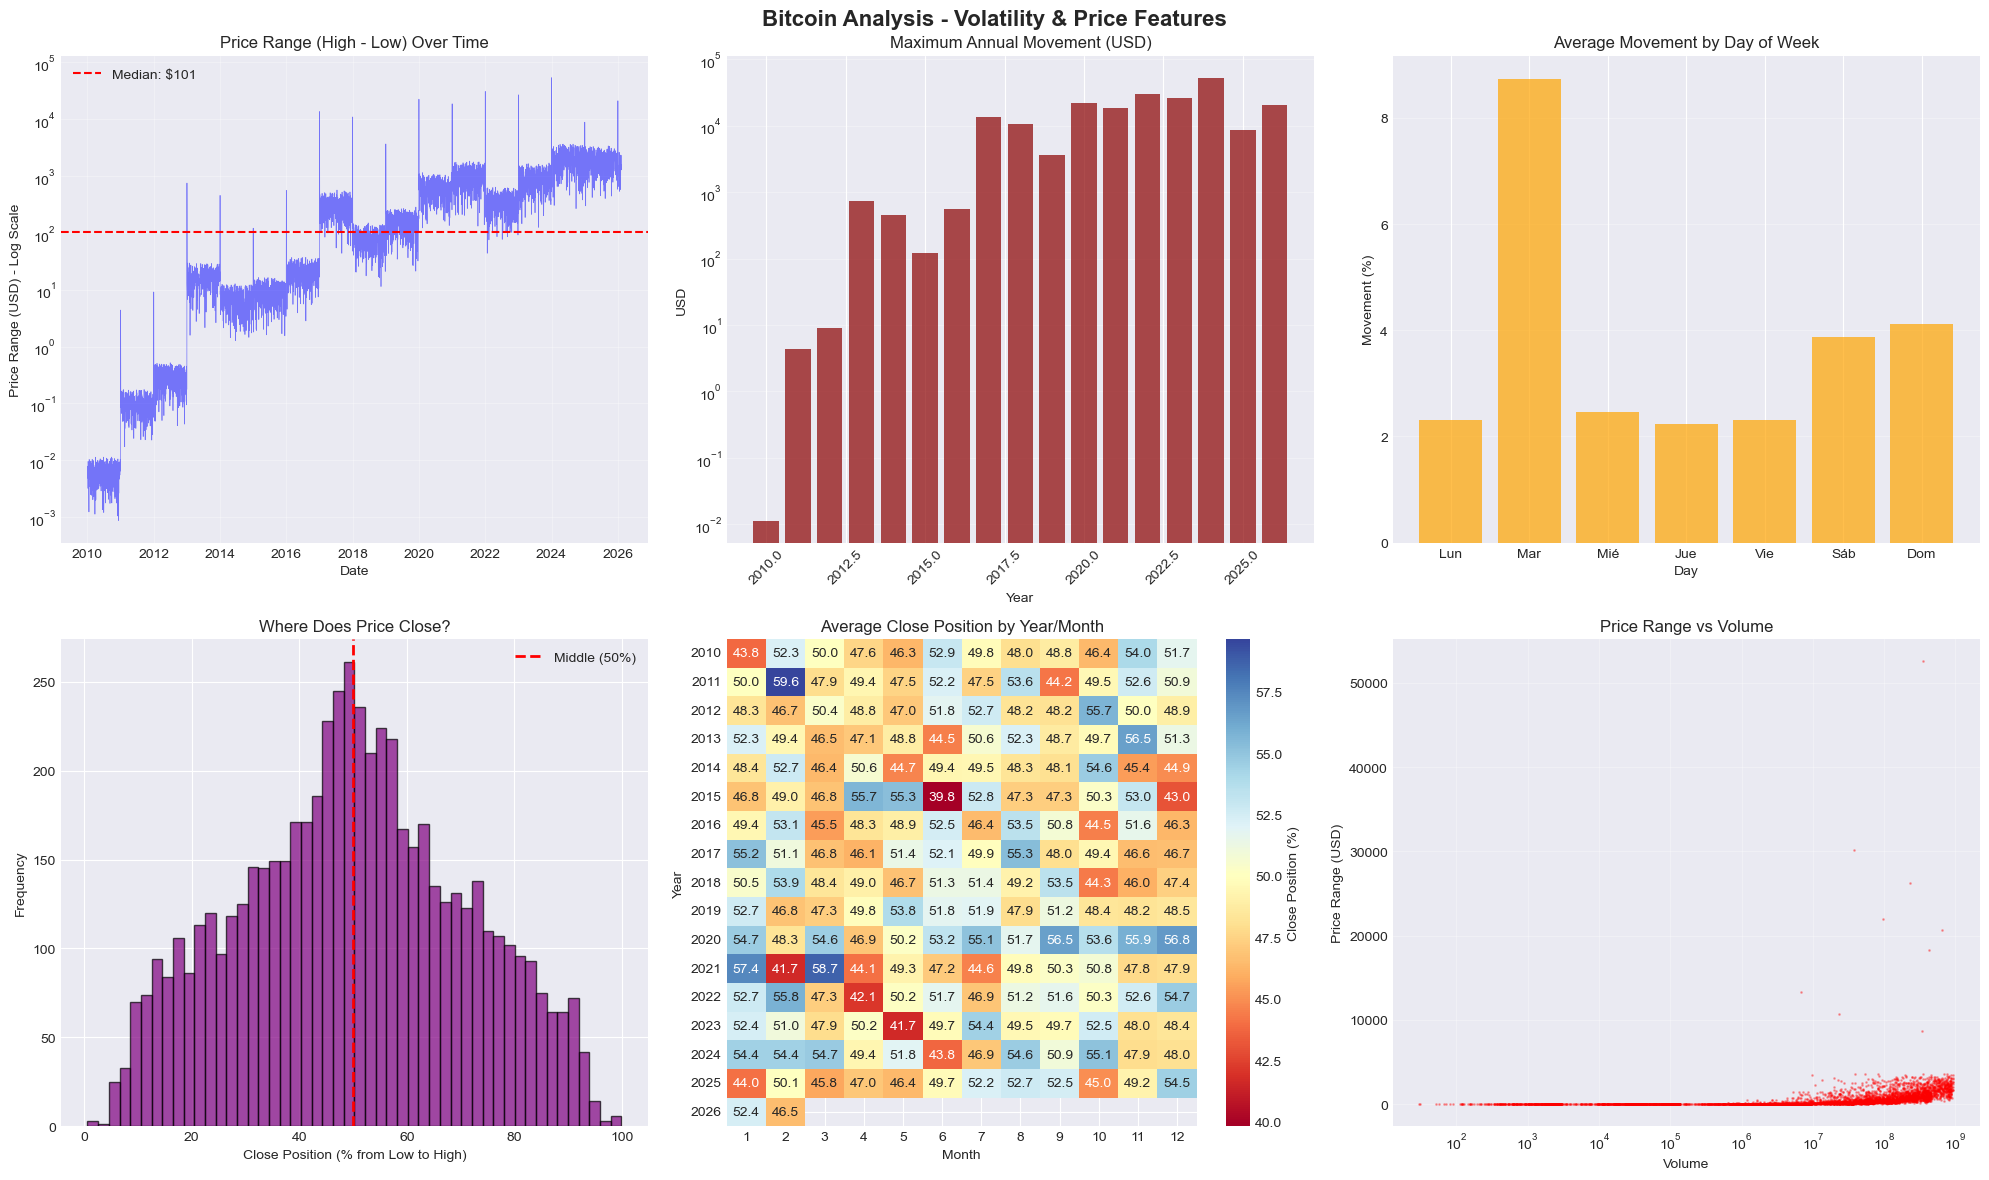

In [47]:
# Create a figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Bitcoin Analysis - Volatility & Price Features', fontsize=16, fontweight='bold')

# ─────────────────────────────────────────────────────────────
#  1: Price Range over time (posición [0,0])
# ─────────────────────────────────────────────────────────────
axes[0, 0].set_yscale('log')
axes[0, 0].plot(bitcoin_analyzed['Date'], bitcoin_analyzed['PriceRange'], 
                alpha=0.5, linewidth=0.5, color='blue')
axes[0, 0].axhline(y=bitcoin_analyzed['PriceRange'].median(), color='red', linestyle='--', 
                   label=f'Median: ${bitcoin_analyzed["PriceRange"].median():.0f}')
axes[0, 0].set_title('Price Range (High - Low) Over Time', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price Range (USD) - Log Scale')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# ─────────────────────────────────────────────────────────────
#  2: Maximum Annual Movement (posición [0,1])
# ─────────────────────────────────────────────────────────────
max_by_year = bitcoin_analyzed.groupby('Year')['PriceRange'].max()
axes[0, 1].bar(max_by_year.index, max_by_year.values, color='darkred', alpha=0.7)
axes[0, 1].set_title('Maximum Annual Movement (USD)', fontsize=12)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('USD')
axes[0, 1].set_yscale('log')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
#  3: Movement by Day of Week (posición [0,2])
# ─────────────────────────────────────────────────────────────
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_names_es = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

mov_by_day = [bitcoin_analyzed[bitcoin_analyzed['DayOfWeek'] == day]['PriceRange_Pct'].mean() 
              for day in day_order]
axes[0, 2].bar(day_names_es, mov_by_day, color='orange', alpha=0.7)
axes[0, 2].set_title('Average Movement by Day of Week', fontsize=12)
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_ylabel('Movement (%)')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# ─────────────────────────────────────────────────────────────
#  4: Close Position Distribution (posición [1,0])
# ─────────────────────────────────────────────────────────────
axes[1, 0].hist(bitcoin_analyzed['Close_Position'].dropna(), bins=50, 
                edgecolor='black', alpha=0.7, color='purple')
axes[1, 0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Middle (50%)')
axes[1, 0].set_title('Where Does Price Close?', fontsize=12)
axes[1, 0].set_xlabel('Close Position (% from Low to High)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# ─────────────────────────────────────────────────────────────
#  5: Close Position Heatmap by Year/Month (posición [1,1])
# ─────────────────────────────────────────────────────────────
pivot_close = bitcoin_analyzed.pivot_table(
    values='Close_Position', 
    index='Year', 
    columns='Month',
    aggfunc='mean'
)
sns.heatmap(pivot_close, annot=True, fmt='.1f', cmap='RdYlBu', center=50, 
            ax=axes[1, 1], cbar_kws={'label': 'Close Position (%)'})
axes[1, 1].set_title('Average Close Position by Year/Month', fontsize=12)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Year')

# ─────────────────────────────────────────────────────────────
#  6: Price Range vs Volume (posición [1,2])
# ─────────────────────────────────────────────────────────────
axes[1, 2].scatter(bitcoin_analyzed['Volume'], bitcoin_analyzed['PriceRange'], 
                   alpha=0.3, s=1, color='red')
axes[1, 2].set_xlabel('Volume')
axes[1, 2].set_ylabel('Price Range (USD)')
axes[1, 2].set_title('Price Range vs Volume')
axes[1, 2].set_xscale('log')  # Log scale for volume
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 1️⃣ Price Range Over Time
**Question:** How has Bitcoin's daily price range changed?  
- Periods of high volatility appear as spikes above the median.

---

 2️⃣ Maximum Annual Movement
**Question:** Which years had the largest price swings?  
- Logarithmic view highlights the most volatile years.

---

 3️⃣ Average Movement by Day of Week
**Question:** Are some weekdays more volatile?  
- Tuesdays show slightly higher average movements.

---

 4️⃣ Close Position Distribution
**Question:** Where does price usually close within the daily range?  
- Most closes are near the middle, rarely at extremes.

---

 5️⃣ Average Close Position by Year/Month
**Question:** How does closing behavior change seasonally?  
- Heatmap shows trends in higher or lower closes by month/year.

---

 6️⃣ Price Range vs Volume
**Question:** Does trading volume relate to volatility?  
- Higher volume sometimes aligns with larger price swings, but not always.

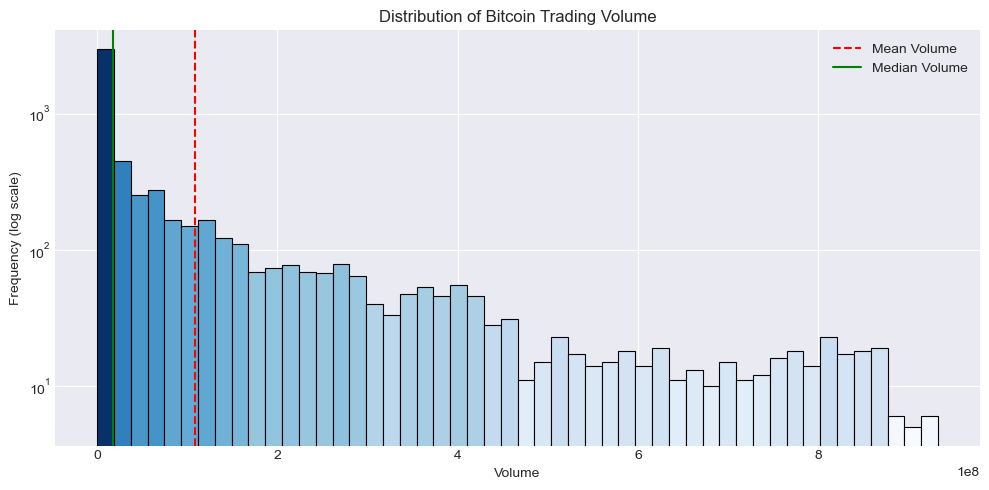

In [85]:

plt.figure(figsize=(10,5))

# Calcular histograma
counts, bins, patches = plt.hist(bitcoin['Volume'], bins=50, edgecolor='black')

# Normalizar usando log de counts para mejor contraste
norm = plt.Normalize(np.log1p(counts).min(), np.log1p(counts).max())

# Aplicar colormap con bordes negros
for count, patch in zip(counts, patches):
    color = cm.Blues(norm(np.log1p(count)))
    patch.set_facecolor(color)
    patch.set_edgecolor('black')   # borde negro
    patch.set_linewidth(0.8)

plt.yscale('log')
plt.axvline(bitcoin['Volume'].mean(), color='red', linestyle='--', label='Mean Volume')
plt.axvline(bitcoin['Volume'].median(), color='green', linestyle='-', label='Median Volume')

plt.title("Distribution of Bitcoin Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

## Volatility Analysis

Volatility is a defining characteristic of cryptocurrency markets.
In this section we analyze how Bitcoin's daily volatility behaves
across different time periods.

Volatility is measured using the daily price range (High - Low) and
its percentage relative to the closing price.

The following visualizations explore:

• The overall distribution of daily price ranges  
• Average volatility patterns across weekdays  
• The statistical characteristics of volatility in the dataset

In [70]:
bitcoin_analyzed[['PriceRange','Volatility']].describe()

,PriceRange,Volatility
count,5883.000000,5883.000000
mean,486.140001,2.309650
std,1209.523009,5.634973
min,0.000880,0.209104
25%,7.337115,1.512438
50%,101.248532,2.068480
75%,628.319497,2.656443
max,52563.116823,286.978595


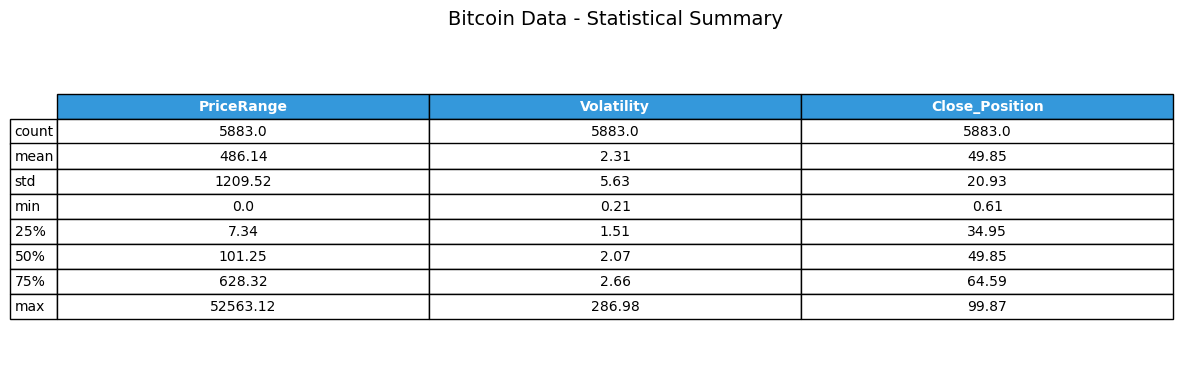

In [27]:
# Create a statistical summary table visualization
fig3, ax3 = plt.subplots(figsize=(12, 4))

# Calculate statistics
stats = bitcoin_analyzed[['PriceRange', 'Volatility', 'Close_Position']].describe().round(2)

# Hide axes
ax3.axis('tight')
ax3.axis('off')

# Create table
table = ax3.table(cellText=stats.values,
                  rowLabels=stats.index,
                  colLabels=stats.columns,
                  cellLoc='center',
                  loc='center',
                  colColours=['#3498db']*3)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Color the header
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#3498db')
        cell.set_text_props(color='white', weight='bold')

ax3.set_title('Bitcoin Data - Statistical Summary', fontsize=14, pad=20)
plt.show()

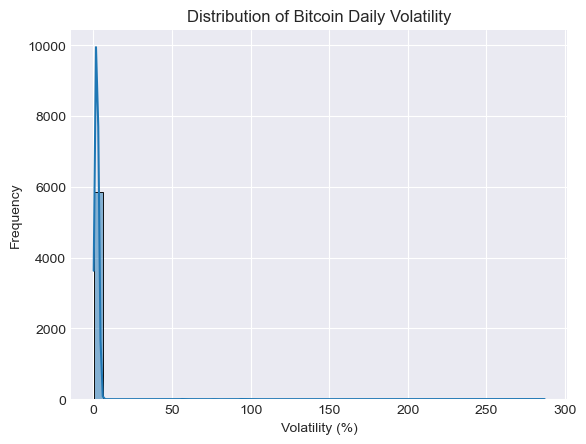

In [87]:
sns.histplot(bitcoin_analyzed['Volatility'], bins=50, kde=True)

plt.title("Distribution of Bitcoin Daily Volatility")
plt.xlabel("Volatility (%)")
plt.ylabel("Frequency")

plt.show()

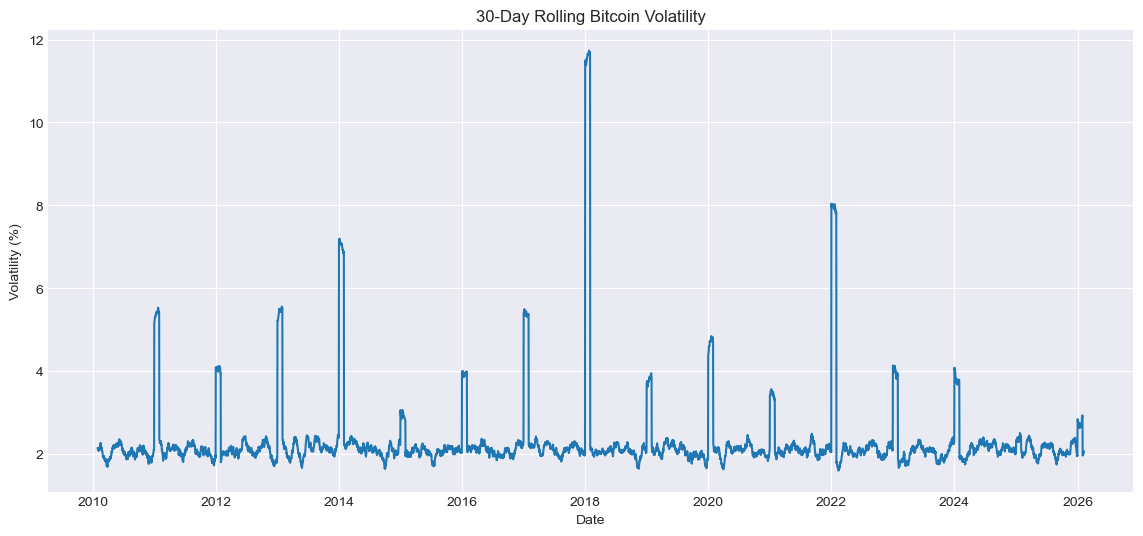

In [88]:
bitcoin_analyzed['RollingVolatility'] = bitcoin_analyzed['Volatility'].rolling(30).mean()

plt.figure(figsize=(14,6))

plt.plot(
    bitcoin_analyzed['Date'],
    bitcoin_analyzed['RollingVolatility']
)

plt.title("30-Day Rolling Bitcoin Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.show()

In [90]:
largest_moves = bitcoin_analyzed.nlargest(5, 'PriceRange')
largest_drops = bitcoin_analyzed.nsmallest(5, 'Close_Position')

largest_moves[['Date','PriceRange','Volatility']]

,Date,PriceRange,Volatility
5113,2024-01-01,52563.116823,56.259838
4383,2022-01-01,30112.221512,181.974446
4748,2023-01-01,26238.918697,62.081630
3652,2020-01-01,22004.792201,75.874094
5844,2026-01-01,20652.392514,29.931004


In [ ]:
threshold = bitcoin_analyzed['Volatility'].quantile(0.99)

extreme_days = bitcoin_analyzed[bitcoin_analyzed['Volatility'] >= threshold]

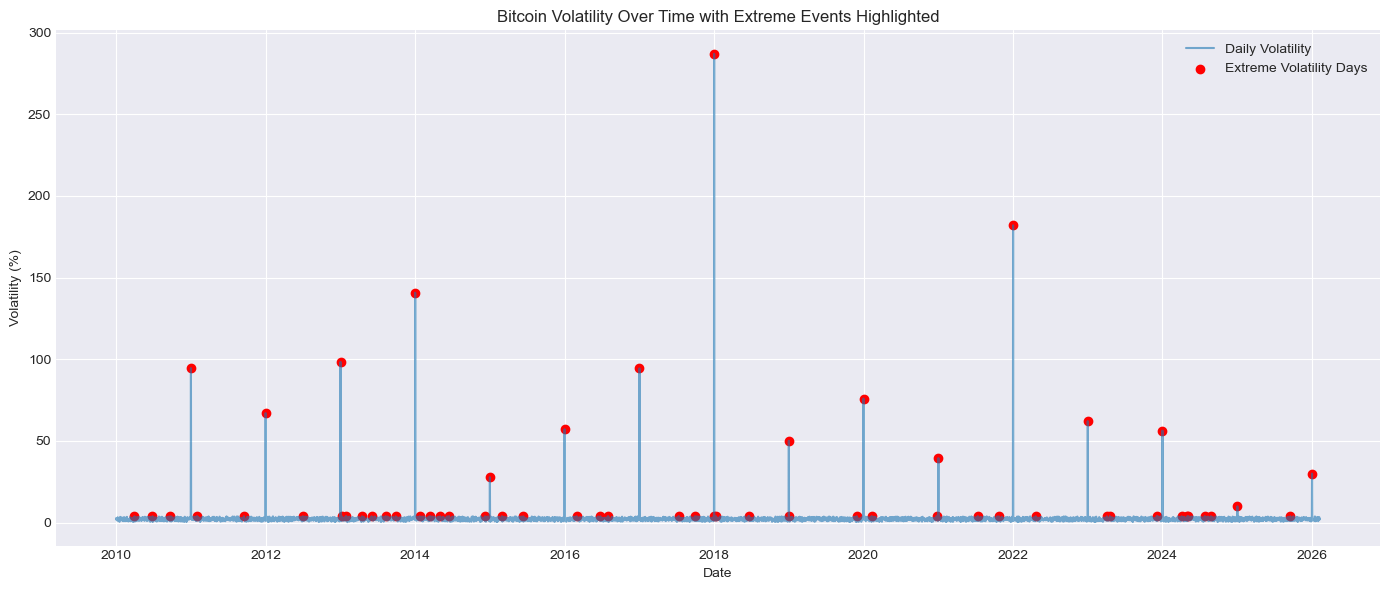

In [89]:
plt.figure(figsize=(14,6))

plt.plot(
    bitcoin_analyzed['Date'],
    bitcoin_analyzed['Volatility'],
    alpha=0.6,
    label="Daily Volatility"
)

plt.scatter(
    extreme_days['Date'],
    extreme_days['Volatility'],
    color='red',
    label="Extreme Volatility Days"
)

plt.title("Bitcoin Volatility Over Time with Extreme Events Highlighted")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.legend()

plt.tight_layout()
plt.show()

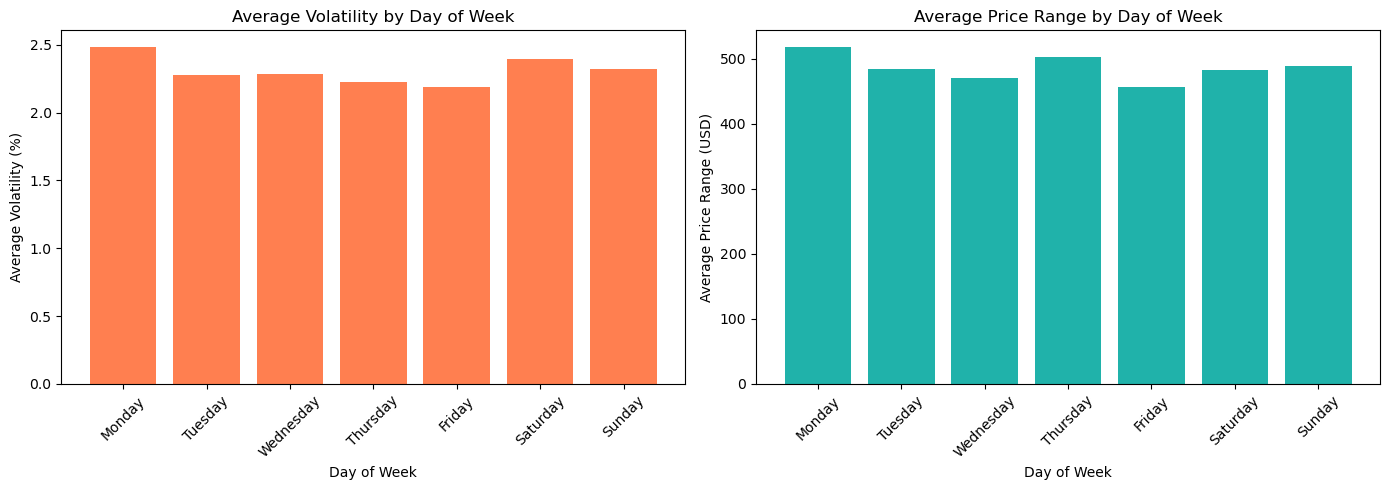

In [28]:
# Analyze volatility by day of week
bitcoin_analyzed['DayOfWeek'] = pd.to_datetime(bitcoin_analyzed['Date']).dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig4, (ax4_1, ax4_2) = plt.subplots(1, 2, figsize=(14, 5))

# Average volatility by day
vol_by_day = bitcoin_analyzed.groupby('DayOfWeek')['Volatility'].mean().reindex(day_order)
ax4_1.bar(vol_by_day.index, vol_by_day.values, color='coral')
ax4_1.set_title('Average Volatility by Day of Week')
ax4_1.set_xlabel('Day of Week')
ax4_1.set_ylabel('Average Volatility (%)')
ax4_1.tick_params(axis='x', rotation=45)

# Average PriceRange by day
range_by_day = bitcoin_analyzed.groupby('DayOfWeek')['PriceRange'].mean().reindex(day_order)
ax4_2.bar(range_by_day.index, range_by_day.values, color='lightseagreen')
ax4_2.set_title('Average Price Range by Day of Week')
ax4_2.set_xlabel('Day of Week')
ax4_2.set_ylabel('Average Price Range (USD)')
ax4_2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

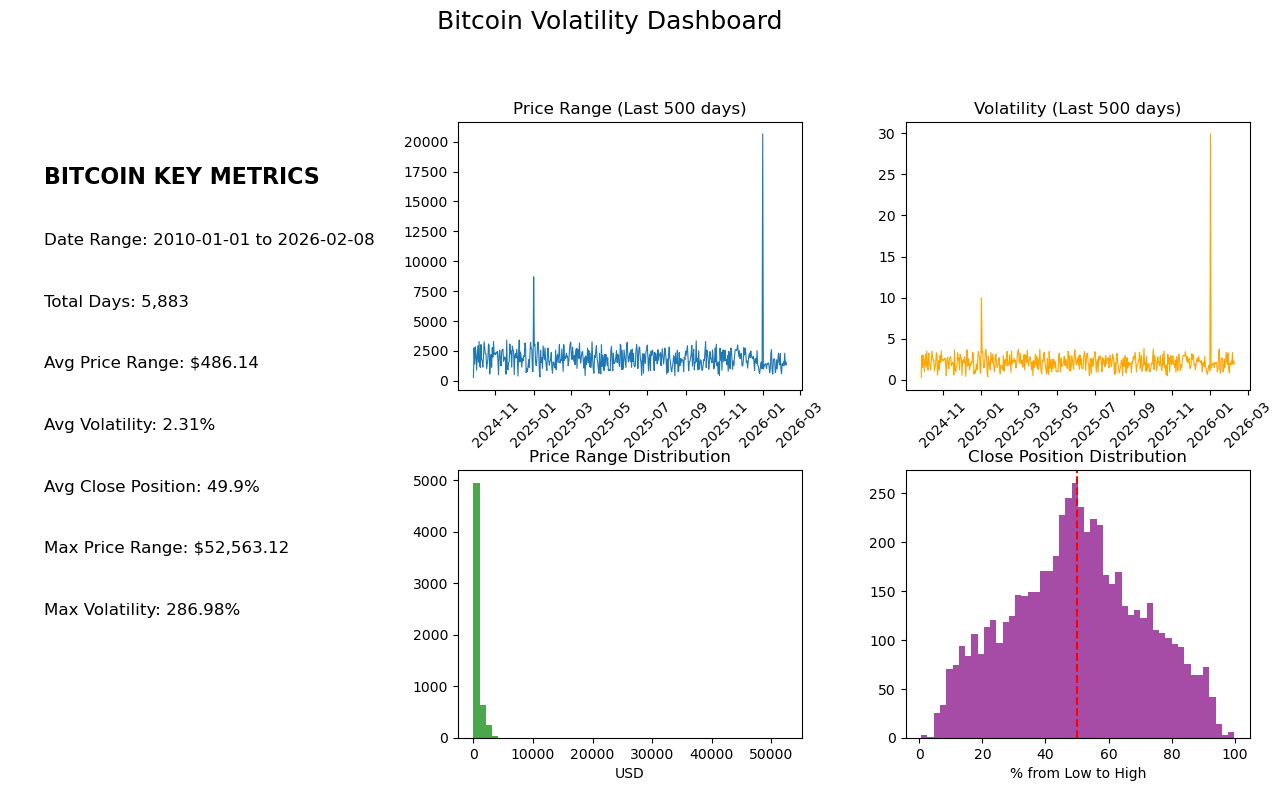

In [29]:
# Create a dashboard of key metrics
fig5 = plt.figure(figsize=(16, 8))
gs = fig5.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# Overall stats as text
ax_main = fig5.add_subplot(gs[:, 0])
ax_main.axis('off')
ax_main.text(0.1, 0.9, 'BITCOIN KEY METRICS', fontsize=16, weight='bold')
ax_main.text(0.1, 0.8, f"Date Range: {bitcoin_analyzed['Date'].min().strftime('%Y-%m-%d')} to {bitcoin_analyzed['Date'].max().strftime('%Y-%m-%d')}", fontsize=12)
ax_main.text(0.1, 0.7, f"Total Days: {len(bitcoin_analyzed):,}", fontsize=12)
ax_main.text(0.1, 0.6, f"Avg Price Range: ${bitcoin_analyzed['PriceRange'].mean():,.2f}", fontsize=12)
ax_main.text(0.1, 0.5, f"Avg Volatility: {bitcoin_analyzed['Volatility'].mean():.2f}%", fontsize=12)
ax_main.text(0.1, 0.4, f"Avg Close Position: {bitcoin_analyzed['Close_Position'].mean():.1f}%", fontsize=12)
ax_main.text(0.1, 0.3, f"Max Price Range: ${bitcoin_analyzed['PriceRange'].max():,.2f}", fontsize=12)
ax_main.text(0.1, 0.2, f"Max Volatility: {bitcoin_analyzed['Volatility'].max():.2f}%", fontsize=12)

# Price Range trend
ax1 = fig5.add_subplot(gs[0, 1])
ax1.plot(bitcoin_analyzed['Date'].tail(500), bitcoin_analyzed['PriceRange'].tail(500), linewidth=0.8)
ax1.set_title('Price Range (Last 500 days)')
ax1.tick_params(axis='x', rotation=45)

# Volatility trend
ax2 = fig5.add_subplot(gs[0, 2])
ax2.plot(bitcoin_analyzed['Date'].tail(500), bitcoin_analyzed['Volatility'].tail(500), linewidth=0.8, color='orange')
ax2.set_title('Volatility (Last 500 days)')
ax2.tick_params(axis='x', rotation=45)

# PriceRange histogram
ax3 = fig5.add_subplot(gs[1, 1])
ax3.hist(bitcoin_analyzed['PriceRange'].dropna(), bins=50, color='green', alpha=0.7)
ax3.set_title('Price Range Distribution')
ax3.set_xlabel('USD')

# Close Position histogram
ax4 = fig5.add_subplot(gs[1, 2])
ax4.hist(bitcoin_analyzed['Close_Position'].dropna(), bins=50, color='purple', alpha=0.7)
ax4.set_title('Close Position Distribution')
ax4.set_xlabel('% from Low to High')
ax4.axvline(x=50, color='red', linestyle='--')

plt.suptitle('Bitcoin Volatility Dashboard', fontsize=18, y=1.02)
plt.show()

## PriceCategory Analysis

🔍 PRICECATEGORY ANALYSIS

📊 DAY DISTRIBUTION BY CATEGORY:
PriceCategory
High      1866
Low       2191
Medium    1826
Name: count, dtype: int64

Percentages:
PriceCategory
High      31.7%
Low       37.2%
Medium    31.0%
Name: count, dtype: object

📈 PRICE STATISTICS BY CATEGORY

🔹 CATEGORY: Low
----------------------------------------
          Open     High      Low    Close
count  2191.00  2191.00  2191.00  2191.00
mean    253.56   256.69   250.72   253.76
std     279.94   283.16   276.79   279.91
min       0.30     0.30     0.29     0.30
25%       4.61     4.65     4.56     4.61
50%      13.53    13.80    13.52    13.53
75%     430.57   435.08   426.13   430.57
max     754.01   769.06   753.23   754.01

📅 Date range: 2010-01-01 to 2015-12-31
📊 Avg volatility (High-Low): $5.97
📊 Avg volatility (%): 2.28%

🔹 CATEGORY: Medium
----------------------------------------
           Open      High       Low     Close
count   1826.00   1826.00   1826.00   1826.00
mean    8529.24   8626.95   84

C:\Users\aleja\AppData\Local\Temp\ipykernel_46692\2608423220.py:59: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(price_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
C:\Users\aleja\AppData\Local\Temp\ipykernel_46692\2608423220.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(vol_data, labels=['Low', 'Medium', 'High'], patch_artist=True)


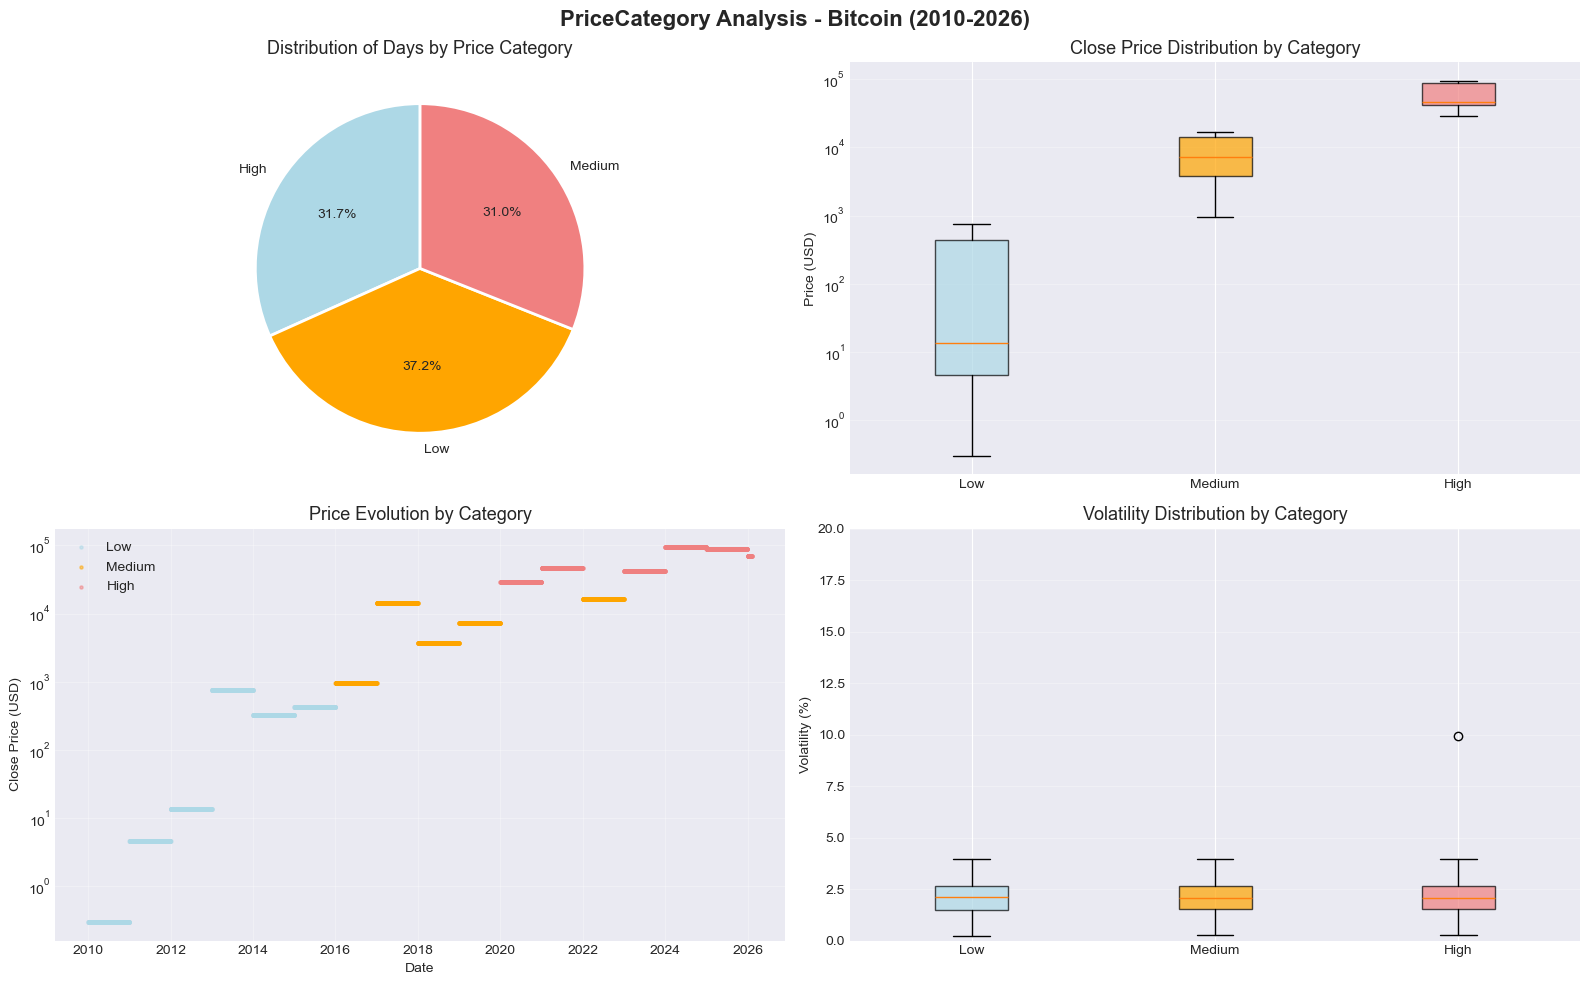

In [53]:

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# ─────────────────────────────────────────────────────────────
# 1. CATEGORY DISTRIBUTION (how many days in each?)
# ─────────────────────────────────────────────────────────────
print("🔍 PRICECATEGORY ANALYSIS")
print("=" * 60)

# Count days by category
category_counts = bitcoin_analyzed['PriceCategory'].value_counts().sort_index()
print("\n📊 DAY DISTRIBUTION BY CATEGORY:")
print(category_counts)
print(f"\nPercentages:")
print((category_counts / len(bitcoin_analyzed) * 100).round(1).astype(str) + '%')

# ─────────────────────────────────────────────────────────────
# 2. DESCRIPTIVE STATISTICS BY CATEGORY
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("📈 PRICE STATISTICS BY CATEGORY")
print("=" * 60)

# Select price columns to analyze
price_columns = ['Open', 'High', 'Low', 'Close']

for category in ['Low', 'Medium', 'High']:
    print(f"\n🔹 CATEGORY: {category}")
    print("-" * 40)
    
    # Filter data for this category
    category_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    
    # Descriptive statistics
    stats = category_data[price_columns].describe()
    print(stats.round(2))
    
    # Additional information
    print(f"\n📅 Date range: {category_data['Date'].min().strftime('%Y-%m-%d')} to {category_data['Date'].max().strftime('%Y-%m-%d')}")
    print(f"📊 Avg volatility (High-Low): ${category_data['PriceRange'].mean():.2f}")
    print(f"📊 Avg volatility (%): {category_data['Volatility'].mean():.2f}%")

# ─────────────────────────────────────────────────────────────
# 3. VISUALIZATIONS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PriceCategory Analysis - Bitcoin (2010-2026)', fontsize=16, fontweight='bold')

# Chart 1: Category distribution (pie chart)
colors = ['lightblue', 'orange', 'lightcoral']
axes[0, 0].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
               colors=colors, startangle=90,
               wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0, 0].set_title('Distribution of Days by Price Category', fontsize=13)

# Chart 2: Boxplot of prices by category
price_data = [bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == cat]['Close'] 
              for cat in ['Low', 'Medium', 'High']]
bp = axes[0, 1].boxplot(price_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
for box, color in zip(bp['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
axes[0, 1].set_title('Close Price Distribution by Category', fontsize=13)
axes[0, 1].set_ylabel('Price (USD)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Chart 3: Temporal evolution by category
colors_map = {'Low': 'lightblue', 'Medium': 'orange', 'High': 'lightcoral'}
for category in ['Low', 'Medium', 'High']:
    cat_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    axes[1, 0].scatter(cat_data['Date'], cat_data['Close'], 
                       label=category, color=colors_map[category], 
                       alpha=0.5, s=5)
axes[1, 0].set_title('Price Evolution by Category', fontsize=13)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Close Price (USD)')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Volatility by category
vol_data = [bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == cat]['Volatility'] 
            for cat in ['Low', 'Medium', 'High']]
bp2 = axes[1, 1].boxplot(vol_data, labels=['Low', 'Medium', 'High'], patch_artist=True)
for box, color in zip(bp2['boxes'], colors):
    box.set_facecolor(color)
    box.set_alpha(0.7)
axes[1, 1].set_title('Volatility Distribution by Category', fontsize=13)
axes[1, 1].set_ylabel('Volatility (%)')
axes[1, 1].set_ylim(0, 20)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [49]:
print("\n" + "=" * 60)
print("📊 PRICECATEGORY SUMMARY TABLE")
print("=" * 60)

summary_data = []
for category in ['Low', 'Medium', 'High']:
    cat_data = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]
    
    summary_data.append({
        'Category': category,
        'Days': len(cat_data),
        'Percentage': f"{len(cat_data)/len(bitcoin_analyzed)*100:.1f}%",
        'Price Range': f"${cat_data['Close'].min():.0f} - ${cat_data['Close'].max():.0f}",
        'Mean Close': f"${cat_data['Close'].mean():.0f}",
        'Median Close': f"${cat_data['Close'].median():.0f}",
        'Mean Volatility': f"{cat_data['Volatility'].mean():.1f}%",
        'Period': f"{cat_data['Date'].min().strftime('%Y')}-{cat_data['Date'].max().strftime('%Y')}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


📊 PRICECATEGORY SUMMARY TABLE
Category  Days Percentage     Price Range Mean Close Median Close Mean Volatility    Period
     Low  2191      37.2%       $0 - $754       $254          $14            2.3% 2010-2015
  Medium  1826      31.0%   $964 - $16548      $8517        $7194            2.4% 2016-2022
    High  1866      31.7% $29002 - $93429     $59898       $46306            2.2% 2020-2026


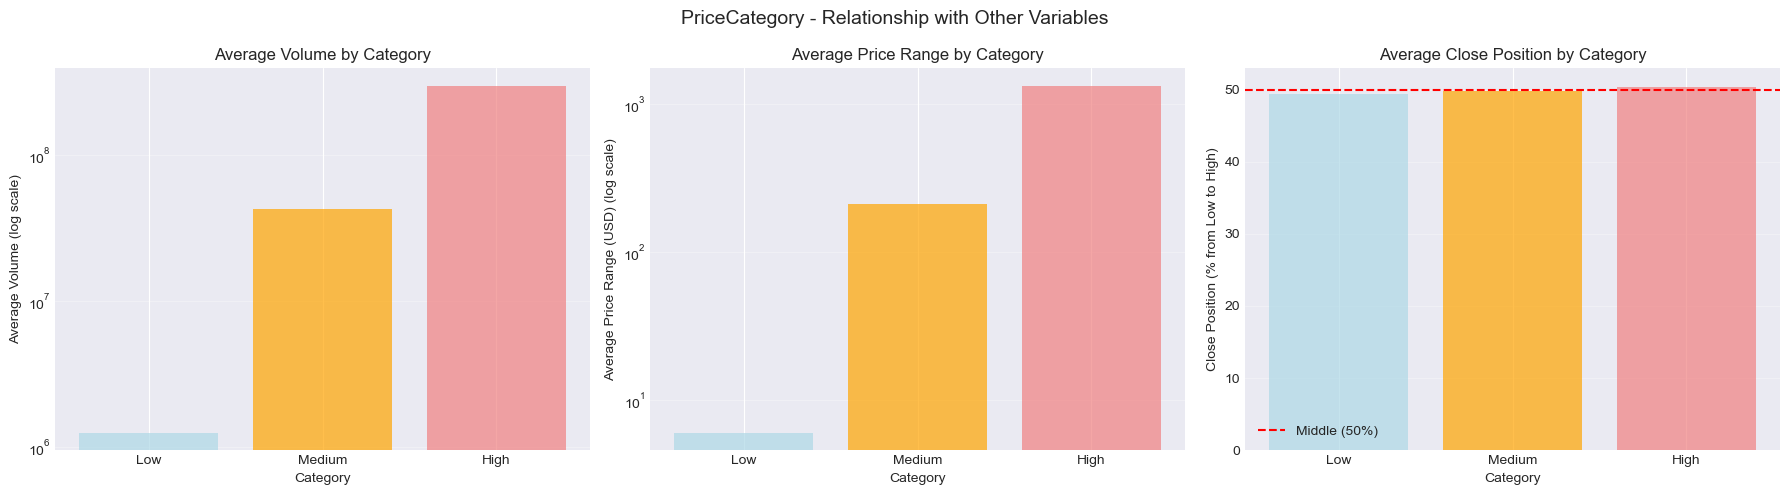

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PriceCategory - Relationship with Other Variables', fontsize=14)

# 1. Volume by category (con escala log)
for i, category in enumerate(['Low', 'Medium', 'High']):
    vol_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['Volume'].mean()
    axes[0].bar(i, vol_mean, color=colors[i], alpha=0.7, label=category)
axes[0].set_title('Average Volume by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Average Volume (log scale)')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['Low', 'Medium', 'High'])
axes[0].set_yscale('log')  
axes[0].grid(True, alpha=0.3, axis='y')

# 2. PriceRange by category 
for i, category in enumerate(['Low', 'Medium', 'High']):
    range_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['PriceRange'].mean()
    axes[1].bar(i, range_mean, color=colors[i], alpha=0.7)
axes[1].set_title('Average Price Range by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Average Price Range (USD) (log scale)')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].set_yscale('log')  
axes[1].grid(True, alpha=0.3, axis='y')

# 3. Close Position by category
for i, category in enumerate(['Low', 'Medium', 'High']):
    pos_mean = bitcoin_analyzed[bitcoin_analyzed['PriceCategory'] == category]['Close_Position'].mean()
    axes[2].bar(i, pos_mean, color=colors[i], alpha=0.7)
axes[2].axhline(y=50, color='red', linestyle='--', label='Middle (50%)')
axes[2].set_title('Average Close Position by Category')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Close Position (% from Low to High)')
axes[2].set_xticks(range(3))
axes[2].set_xticklabels(['Low', 'Medium', 'High'])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [56]:
print("\n" + "=" * 60)
print("🔍 PRICECATEGORY INTERPRETATION")
print("=" * 60)

print("""
📌 WHAT DOES EACH CATEGORY MEAN?

• LOW: Low price days (early Bitcoin years, 2010-2013)
   - Very low prices (cents or few dollars)
   - Low USD volatility, same % volatility
   - Low trading volume

• MEDIUM: Growth period (approx. 2014-2020)
   - Intermediate prices ($100 - $10,000)
   - Moderate volatility, same % volatility
   - Developing market

• HIGH: Recent era (2021-2026)
   - High prices (> $10,000)
   - High USD volatility, same % volatility
   - High volume, mature market

📊 DISTRIBUTION SHOULD BE APPROXIMATELY EQUAL
   (33% each) BECAUSE IT WAS CREATED USING QUANTILES.
""")

# Check if distribution is uniform
expected = len(bitcoin_analyzed) / 3
print(f"\n✅ Ideal distribution (33.3% each): {expected:.0f} days per category")
print("📊 Actual distribution:")
for cat, count in category_counts.items():
    diff = ((count - expected) / expected * 100)
    print(f"   {cat}: {count} days ({diff:+.1f}% vs ideal)")


🔍 PRICECATEGORY INTERPRETATION

📌 WHAT DOES EACH CATEGORY MEAN?

• LOW: Low price days (early Bitcoin years, 2010-2013)
   - Very low prices (cents or few dollars)
   - Low USD volatility, same % volatility
   - Low trading volume

• MEDIUM: Growth period (approx. 2014-2020)
   - Intermediate prices ($100 - $10,000)
   - Moderate volatility, same % volatility
   - Developing market

• HIGH: Recent era (2021-2026)
   - High prices (> $10,000)
   - High USD volatility, same % volatility
   - High volume, mature market

📊 DISTRIBUTION SHOULD BE APPROXIMATELY EQUAL
   (33% each) BECAUSE IT WAS CREATED USING QUANTILES.


✅ Ideal distribution (33.3% each): 1961 days per category
📊 Actual distribution:
   High: 1866 days (-4.8% vs ideal)
   Low: 2191 days (+11.7% vs ideal)
   Medium: 1826 days (-6.9% vs ideal)
